In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikitplot as skplt

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn import ensemble  as en

import suporte_modelos as sm

## 0.1 Help functions

In [2]:
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

## 0.2 Load Data

In [3]:
x_treino = sm.load_pickle(DATA_DIR / "x_treino.pkl")
y_treino = sm.load_pickle(DATA_DIR / "y_treino.pkl")

x_teste = sm.load_pickle(DATA_DIR / "x_teste.pkl")
y_teste = sm.load_pickle(DATA_DIR / "y_teste.pkl")

x_validacao = sm.load_pickle(DATA_DIR / "x_validacao.pkl")
y_validacao = sm.load_pickle(DATA_DIR / "y_validacao.pkl")

In [4]:
cols_selected = sm.load_pickle(DATA_DIR / "cols_selected.pkl")

In [5]:
x_lista_df = [x_teste,x_validacao]
y_lista_df = [y_teste,y_validacao]

In [6]:
lista_df = sm.aplicar_modificacoes(x_data_frame = x_lista_df, y_data_frame= y_lista_df, response="resposta", cols_select=cols_selected)

In [7]:
x_teste, y_teste, x_validacao, y_validacao = sm.separar_df(lista_df=lista_df, response="resposta")

# 1.0 Fine-Tunning (Random Search)

## 1.1 XGBoost

In [8]:
xgb_dist = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "scale_pos_weight": [1, 2, 3, 5, 8]
}
MAX_EVAL = 30

In [ ]:
final_result = pd.DataFrame()

for i in range(MAX_EVAL):
    print(f"Itera??o: {i + 1}")

    params = {k: random.choice(v) for k, v in xgb_dist.items()}
    print(params)

    model_xgb = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        scale_pos_weight=params["scale_pos_weight"],
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    result = sm.cross_val(
        modelo=model_xgb,
        kfold=5,
        x_dados=x_treino,
        y_dados=y_treino
    )

    params_df = pd.DataFrame([params])
    params_df["iteracao"] = i + 1

    resultado_iteracao = pd.concat(
        [params_df.reset_index(drop=True), result.reset_index(drop=True)],
        axis=1
    )

    final_result = pd.concat([final_result, resultado_iteracao], ignore_index=True)

final_result = final_result.sort_values(by="Recall@k Mean", ascending=False).reset_index(drop=True)
final_result

Itera??o: 1
{'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 1.0, 'colsample_bytree': 1.0, 'scale_pos_weight': 1}
1/5
2/5
3/5
4/5
5/5
Itera??o: 2
{'n_estimators': 800, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 2}
1/5
2/5
3/5
4/5
5/5
Itera??o: 3
{'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.5, 'colsample_bytree': 0.7, 'scale_pos_weight': 2}
1/5
2/5
3/5
4/5
5/5
Itera??o: 4
{'n_estimators': 800, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.8, 'scale_pos_weight': 3}
1/5
2/5
3/5
4/5
5/5
Itera??o: 5
{'n_estimators': 800, 'learning_rate': 0.2, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.7, 'scale_pos_weight': 1}
1/5
2/5
3/5
4/5
5/5
Itera??o: 6
{'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weigh

,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,scale_pos_weight,iteracao,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,200,0.01,10,5,0.8,0.6,3,22,XGBClassifier,0.262199,0.000992,0.966382,0.003693
1,100,0.01,10,1,0.7,0.8,5,7,XGBClassifier,0.262099,0.001041,0.966014,0.003873
2,500,0.03,5,10,0.5,0.6,3,9,XGBClassifier,0.262082,0.001134,0.965952,0.004214
3,500,0.03,3,10,1.0,0.7,2,27,XGBClassifier,0.262082,0.001038,0.965952,0.003862
4,300,0.10,3,5,1.0,0.7,5,18,XGBClassifier,0.262057,0.001129,0.965860,0.004194
5,800,0.03,3,5,1.0,0.8,3,4,XGBClassifier,0.262007,0.001090,0.965676,0.004061
6,100,0.20,4,5,1.0,0.9,1,20,XGBClassifier,0.261983,0.001066,0.965584,0.003965
7,300,0.05,4,10,0.5,0.7,2,3,XGBClassifier,0.261983,0.001090,0.965584,0.004051
8,100,0.03,10,7,0.7,0.9,2,12,XGBClassifier,0.261983,0.000980,0.965584,0.003644
9,100,0.03,8,5,1.0,1.0,1,6,XGBClassifier,0.261941,0.001128,0.965431,0.004199


## 1.2 Logistic Regression

In [ ]:
lr_dist = {
    # Controla a forca da regularizacao. Valores menores penalizam mais e ajudam a reduzir overfitting.
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    # Troca o otimizador. Isso pode alterar estabilidade, tempo de treino e qualidade da convergencia.
    "solver": ["lbfgs", "liblinear", "saga"],
    # Ajusta o peso das classes. E importante em classificacao desbalanceada, como em propensao.
    "class_weight": [None, "balanced"],
    # Define o limite de iteracoes para convergencia. Valores maiores evitam parada prematura.
    "max_iter": [200, 500, 1000, 1500],
    # Decide se o modelo deve aprender intercepto. Pode fazer diferenca quando os dados nao estao centrados.
    "fit_intercept": [True, False],
    # Define a tolerancia de parada do otimizador. Impacta velocidade e precisao da convergencia.
    "tol": [1e-5, 1e-4, 1e-3],
}

MAX_EVAL_LR = 30

lr_final_result = pd.DataFrame()

for i in range(MAX_EVAL_LR):
    print(f"Itera??o: {i + 1}")

    params = {k: random.choice(v) for k, v in lr_dist.items()}
    print(params)

    model_lr = LogisticRegression(
        C=params["C"],
        solver=params["solver"],
        class_weight=params["class_weight"],
        max_iter=params["max_iter"],
        fit_intercept=params["fit_intercept"],
        tol=params["tol"],
        random_state=42,
        n_jobs=-1,
    )

    result = sm.cross_val(
        modelo=model_lr,
        kfold=5,
        x_dados=x_treino,
        y_dados=y_treino
    )

    params_df = pd.DataFrame([params])
    params_df["iteracao"] = i + 1

    resultado_iteracao = pd.concat(
        [params_df.reset_index(drop=True), result.reset_index(drop=True)],
        axis=1,
    )

    lr_final_result = pd.concat([lr_final_result, resultado_iteracao], ignore_index=True)

lr_final_result = lr_final_result.sort_values(by="Recall@k Mean", ascending=False).reset_index(drop=True)
lr_final_result

Itera??o: 1
{'C': 10.0, 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1000, 'fit_intercept': True, 'tol': 0.001}
1/5
2/5
3/5
4/5
5/5
Itera??o: 2
{'C': 1.0, 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 200, 'fit_intercept': True, 'tol': 0.001}
1/5


e:\3_recursos\2_area\profissional\cursos\22_06.1 - PA004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


2/5


e:\3_recursos\2_area\profissional\cursos\22_06.1 - PA004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


3/5


...

4/5


e:\3_recursos\2_area\profissional\cursos\22_06.1 - PA004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


5/5


e:\3_recursos\2_area\profissional\cursos\22_06.1 - PA004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


,C,solver,class_weight,max_iter,fit_intercept,tol,iteracao,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,0.01,liblinear,balanced,200,True,0.00001,11,LogisticRegression,0.258159,0.000787,0.951492,0.002938
1,0.10,saga,balanced,1500,True,0.00001,14,LogisticRegression,0.257843,0.000572,0.950326,0.002146
2,1.00,saga,balanced,500,True,0.00010,25,LogisticRegression,0.257826,0.000571,0.950264,0.002149
3,1.00,liblinear,balanced,200,True,0.00100,30,LogisticRegression,0.257809,0.000566,0.950203,0.002130
4,1.00,liblinear,balanced,200,True,0.00100,2,LogisticRegression,0.257809,0.000566,0.950203,0.002130
5,10.00,saga,balanced,1000,True,0.00001,26,LogisticRegression,0.257801,0.000565,0.950172,0.002124
6,100.00,lbfgs,balanced,200,True,0.00001,19,LogisticRegression,0.257801,0.000565,0.950172,0.002124
7,10.00,lbfgs,balanced,500,True,0.00010,10,LogisticRegression,0.257768,0.000597,0.950049,0.002240
8,10.00,saga,balanced,1000,True,0.00100,1,LogisticRegression,0.257768,0.000585,0.950049,0.002198
9,0.01,lbfgs,None,500,True,0.00010,27,LogisticRegression,0.257484,0.000782,0.949005,0.002923


## 1.3 Random Forest

In [ ]:
rf_dist = {
    # Define quantas arvores serao criadas. Mais arvores costumam estabilizar o modelo, com maior custo computacional.
    "n_estimators": [100, 200, 300, 500, 800],
    # Limita a profundidade das arvores. E um dos principais controles de complexidade e overfitting.
    "max_depth": [None, 5, 10, 15, 20, 30],
    # Exige um numero minimo de amostras para dividir um no. Ajuda a evitar regras muito especificas.
    "min_samples_split": [2, 5, 10, 20],
    # Exige um minimo de amostras nas folhas. Tende a suavizar as previsoes e reduzir ruido.
    "min_samples_leaf": [1, 2, 4, 8],
    # Controla quantas features cada arvore avalia por divisao. Aumenta diversidade entre arvores.
    "max_features": ["sqrt", "log2", None],
    # Ajusta o peso das classes para lidar melhor com desbalanceamento da resposta.
    "class_weight": [None, "balanced", "balanced_subsample"],
}

MAX_EVAL_RF = 30

rf_final_result = pd.DataFrame()

for i in range(MAX_EVAL_RF):
    print(f"Itera??o: {i + 1}")

    params = {k: random.choice(v) for k, v in rf_dist.items()}
    print(params)

    model_rf = en.RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        random_state=42,
        n_jobs=-1,
    )

    result = sm.cross_val(
        modelo=model_rf,
        kfold=5,
        x_dados=x_treino,
        y_dados=y_treino
    )

    params_df = pd.DataFrame([params])
    params_df["iteracao"] = i + 1

    resultado_iteracao = pd.concat(
        [params_df.reset_index(drop=True), result.reset_index(drop=True)],
        axis=1,
    )

    rf_final_result = pd.concat([rf_final_result, resultado_iteracao], ignore_index=True)

rf_final_result = rf_final_result.sort_values(by="Recall@k Mean", ascending=False).reset_index(drop=True)
rf_final_result

Itera??o: 1
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}
1/5
2/5
3/5
4/5
5/5
Itera??o: 2
{'n_estimators': 800, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'class_weight': 'balanced_subsample'}
1/5
2/5
3/5
4/5
5/5
Itera??o: 3
{'n_estimators': 800, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': None}
1/5
2/5
3/5
4/5
5/5
Itera??o: 4
{'n_estimators': 500, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}
1/5
2/5
3/5
4/5
5/5
Itera??o: 5
{'n_estimators': 500, 'max_depth': None, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}
1/5
2/5
3/5
4/5
5/5
Itera??o: 6
{'n_estimators': 800, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight'

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,iteracao,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,100,10,10,1,log2,None,15,RandomForestClassifier,0.261708,0.000780,0.964571,0.002910
1,800,15,2,4,sqrt,None,3,RandomForestClassifier,0.261408,0.000971,0.963466,0.003618
2,300,5,2,8,None,None,25,RandomForestClassifier,0.261274,0.000915,0.962974,0.003396
3,200,15,10,4,sqrt,balanced,23,RandomForestClassifier,0.261191,0.001049,0.962668,0.003911
4,200,5,10,4,sqrt,balanced,17,RandomForestClassifier,0.261150,0.000973,0.962514,0.003629
5,100,5,5,1,sqrt,balanced_subsample,10,RandomForestClassifier,0.261150,0.000947,0.962514,0.003535
6,800,5,2,1,log2,balanced,28,RandomForestClassifier,0.261150,0.000914,0.962514,0.003412
7,500,5,5,8,log2,balanced,13,RandomForestClassifier,0.261141,0.000914,0.962483,0.003412
8,500,5,10,8,log2,balanced_subsample,29,RandomForestClassifier,0.261125,0.000894,0.962422,0.003338
9,500,20,20,8,log2,None,14,RandomForestClassifier,0.261033,0.000808,0.962084,0.003031


## 1.4 Melhores

In [23]:
final_result = final_result.sort_values("Recall@k Mean", ascending=False).reset_index(drop=True)
lr_final_result = lr_final_result.sort_values("Recall@k Mean", ascending=False).reset_index(drop=True)
rf_final_result = rf_final_result.sort_values("Recall@k Mean", ascending=False).reset_index(drop=True)

melhores = pd.concat([
                    final_result[["Model_Name", "Recall@k Mean"]].head(3),
                    lr_final_result[["Model_Name", "Recall@k Mean"]].head(3),
                    rf_final_result[["Model_Name", "Recall@k Mean"]].head(3)
                    ], axis=0).sort_values(by='Recall@k Mean',ascending=False)
melhores

,Model_Name,Recall@k Mean
0,XGBClassifier,0.966382
1,XGBClassifier,0.966014
2,XGBClassifier,0.965952
0,RandomForestClassifier,0.964571
1,RandomForestClassifier,0.963466
2,RandomForestClassifier,0.962974
0,LogisticRegression,0.951492
1,LogisticRegression,0.950326
2,LogisticRegression,0.950264


LogistcRegression Descartado

# 2.0 Teste com parâmetros selecionados

In [8]:
x_tr_tes = pd.concat([x_treino, x_teste])
y_tr_tes = pd.concat([y_treino, y_teste])

## 2.1 XGBoost

In [ ]:
final_result.head(1)

### 2.1.1 Treino Teste

In [11]:
model_xgb_tunned = XGBClassifier(
        n_estimators=200,
        learning_rate=0.01,
        max_depth=10,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.6,
        scale_pos_weight=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
model_xgb_tunned.fit(x_treino, y_treino)

y_hat_xgb = model_xgb_tunned.predict_proba( x_teste )

df_xgb = pd.DataFrame({
                "resposta": y_teste.values,
                "score": y_hat_xgb[:, 1]
            })

result = sm.ml_error(model=model_xgb_tunned, data = df_xgb)
result

,Model_Name,precision_at_k,recall_at_k
0,XGBClassifier,0.28339,0.926111


## 2.1.2 Houldout

In [12]:
model_xgb_tunned_hd = XGBClassifier(
        n_estimators=200,
        learning_rate=0.01,
        max_depth=10,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.6,
        scale_pos_weight=3,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
model_xgb_tunned_hd.fit(x_tr_tes, y_tr_tes)

y_hat_xgb_dh = model_xgb_tunned_hd.predict_proba( x_validacao )

df_xgb_hd = pd.DataFrame({
                "resposta": y_validacao.values,
                "score": y_hat_xgb_dh[:, 1]
            })

result = sm.ml_error(model=model_xgb_tunned_hd, data = df_xgb_hd)
result

,Model_Name,precision_at_k,recall_at_k
0,XGBClassifier,0.289294,0.926341


In [13]:
result_cv = sm.cross_val(model_xgb_tunned_hd,5,x_tr_tes,y_tr_tes)
result_cv

1/5
2/5
3/5
4/5
5/5


,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,XGBClassifier,0.281757,0.000548,0.922667,0.001807


## 2.2 Random Forest

In [25]:
rf_final_result.head(1)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,iteracao,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,100,10,10,1,log2,None,15,RandomForestClassifier,0.261708,0.00078,0.964571,0.00291


### 2.1.1 Treino Teste

In [14]:
model_rf_tunned = en.RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=1,
        max_features='log2',
        class_weight=None,
        random_state=42,
        n_jobs=-1,
    )
model_rf_tunned.fit(x_treino, y_treino)

y_hat_rf = model_rf_tunned.predict_proba( x_teste )

df_rf = pd.DataFrame({
                "resposta": y_teste.values,
                "score": y_hat_rf[:, 1]
            })

result = sm.ml_error(model=model_rf_tunned, data = df_rf)
result

,Model_Name,precision_at_k,recall_at_k
0,RandomForestClassifier,0.282384,0.922824


## 2.1.2 Houldout

In [15]:
model_rf_tunned_hd = en.RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=1,
        max_features='log2',
        class_weight=None,
        random_state=42,
        n_jobs=-1,
    )
model_rf_tunned_hd.fit(x_tr_tes, y_tr_tes)

y_hat_rf_dh = model_rf_tunned_hd.predict_proba( x_validacao )

df_rf_hd = pd.DataFrame({
                "resposta": y_validacao.values,
                "score": y_hat_rf_dh[:, 1]
            })

result = sm.ml_error(model=model_rf_tunned_hd, data = df_rf_hd)
result

,Model_Name,precision_at_k,recall_at_k
0,RandomForestClassifier,0.287501,0.920599


In [16]:
result_cv = sm.cross_val(model_rf_tunned_hd,5,x_tr_tes,y_tr_tes)
result_cv

1/5
2/5
3/5
4/5
5/5


,Model_Name,Precision@k Mean,Precision@k STD,Recall@k Mean,Recall@k STD
0,RandomForestClassifier,0.280986,0.000465,0.92014,0.001542


## 2.3 Curva Lift

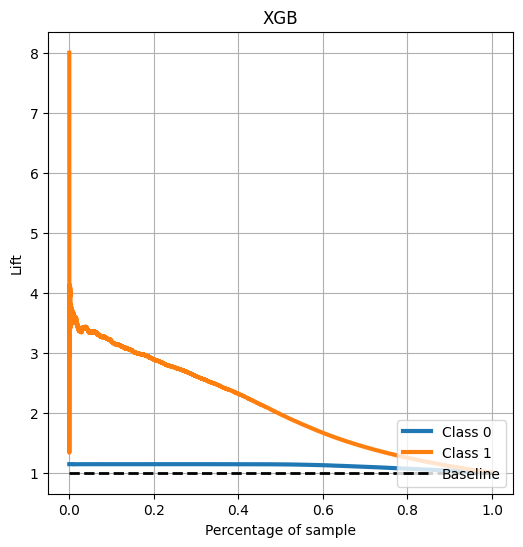

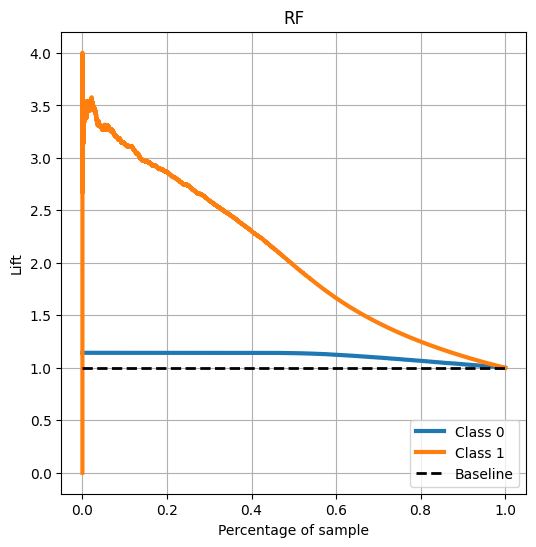

In [41]:
skplt.metrics.plot_lift_curve(y_validacao, y_hat_xgb_dh,figsize =(6,6),title='XGB');
skplt.metrics.plot_lift_curve(y_validacao, y_hat_rf_dh,figsize =(6,6),title='RF');

In [42]:
def metricas_lift(y_true, y_score, top_perc=0.1):
    df = pd.DataFrame({
        "target": y_true,
        "score": y_score
    }).sort_values("score", ascending=False)

    n_top = int(len(df) * top_perc)
    top = df.head(n_top)

    taxa_top = top["target"].mean()
    taxa_global = df["target"].mean()

    lift = taxa_top / taxa_global

    recall = top["target"].sum() / df["target"].sum()
    precision = taxa_top

    return {
        "top_%": top_perc,
        "lift": lift,
        "precision": precision,
        "recall": recall
    }

In [52]:
xgb_metrics = metricas_lift(y_validacao, y_hat_xgb_dh[:, 1], top_perc=0.10)
rf_metrics = metricas_lift(y_validacao, y_hat_rf_dh[:, 1], top_perc=0.10)

comparacao = pd.DataFrame([xgb_metrics, rf_metrics], index=["XGB", "RF"])
comparacao

,top_%,lift,precision,recall
XGB,0.1,3.191653,0.398705,0.319143
RF,0.1,3.137035,0.391882,0.313682


In [45]:
def tabela_lift(y_true, y_score, bins=10):
    df = pd.DataFrame({
        "target": y_true,
        "score": y_score
    }).sort_values("score", ascending=False).reset_index(drop=True)

    df["decil"] = pd.qcut(df.index, bins, labels=False)

    taxa_global = df["target"].mean()

    tabela = df.groupby("decil").agg(
        clientes=("target", "count"),
        positivos=("target", "sum")
    )

    tabela["precision"] = tabela["positivos"] / tabela["clientes"]
    tabela["lift"] = tabela["precision"] / taxa_global

    return tabela

In [50]:
lift_xgb = tabela_lift(y_validacao, y_hat_xgb_dh[:, 1]).reset_index()
lift_xgb

,decil,clientes,positivos,precision,lift
0,0,5717,2280,0.398811,3.192495
1,1,5716,1850,0.323653,2.590855
2,2,5716,1462,0.255773,2.047476
3,3,5717,1023,0.178940,1.432422
4,4,5716,432,0.075577,0.605000
5,5,5716,87,0.015220,0.121840
6,6,5717,2,0.000350,0.002800
7,7,5716,1,0.000175,0.001400
8,8,5716,1,0.000175,0.001400
9,9,5717,3,0.000525,0.004201


In [75]:
percent_xgb = lift_xgb.loc[0:2,["positivos"]].agg("sum").values / lift_xgb.loc[0:2,["clientes"]].agg("sum").values
percent_xgb

array([0.32608315])

In [51]:
lift_rf = tabela_lift(y_validacao, y_hat_rf_dh[:, 1]).reset_index()
lift_rf

,decil,clientes,positivos,precision,lift
0,0,5717,2240,0.391814,3.136486
1,1,5716,1851,0.323828,2.592255
2,2,5716,1462,0.255773,2.047476
3,3,5717,1021,0.178590,1.429622
4,4,5716,483,0.084500,0.676423
5,5,5716,77,0.013471,0.107836
6,6,5717,2,0.000350,0.002800
7,7,5716,2,0.000350,0.002801
8,8,5716,2,0.000350,0.002801
9,9,5717,1,0.000175,0.001400


In [76]:
percent_rf = lift_rf.loc[0:2,["positivos"]].agg("sum").values / lift_rf.loc[0:2,["clientes"]].agg("sum").values
percent_rf

array([0.32380897])

In [77]:
percent_xgb / percent_rf # O XGB ainda consegue pegar mais resultados que o RF.

array([1.00702323])

## 2.3 Tamanho do Modelo

In [36]:
lista_modelos = [model_xgb_tunned_hd, model_rf_tunned_hd]

sm.tamanho_modelo(lista_modelos=lista_modelos)

,model,bytes,KB,MB
0,XGBClassifier,5309623,5185.178711,5.063651
1,RandomForestClassifier,7142175,6974.780273,6.811309


In [ ]:
import pickle

pickle.dump(model_xgb_tunned_hd, open("../models/model_xgb_tunned_hd.pkl", "wb"))

Foi selecionado como modelo final o XGBClassifier.
Critérios:
1. Modelo Leve, com menor tamanho em memória
2. Melhor desempenho na métrica principal Recall@k.
3. A Curva Lift apresentou resultados ligeiramente superiores nos primeiros decis.